# Titanic Survival Analysis
In this notebook, we explore the Titanic passenger data to understand which groups of people were more likely to survive the disaster.

In [15]:
# Import the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the training data
df = pd.read_csv("/kaggle/input/competitions/titanic/train.csv")

# Preview the first 5 rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [16]:
# Fill missing Age values with the median
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill missing Embarked values with the most common value
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Drop the Cabin column (too many missing values)
df = df.drop(columns=["Cabin"], errors="ignore")

# Check that no values are missing now
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

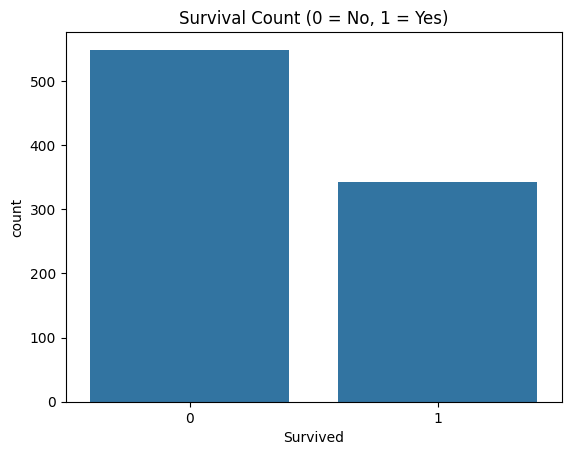

In [17]:
# Count of passengers who survived (1) and who did not (0)
sns.countplot(x="Survived", data=df)
plt.title("Survival Count (0 = No, 1 = Yes)")
plt.show()

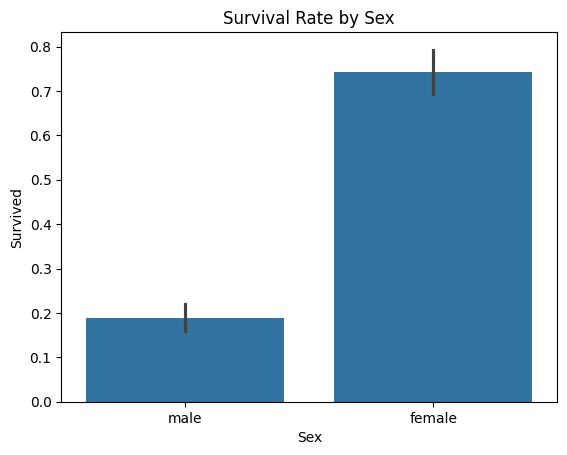

In [18]:
# Survival rate for male and female passengers
sns.barplot(x="Sex", y="Survived", data=df)
plt.title("Survival Rate by Sex")
plt.show()

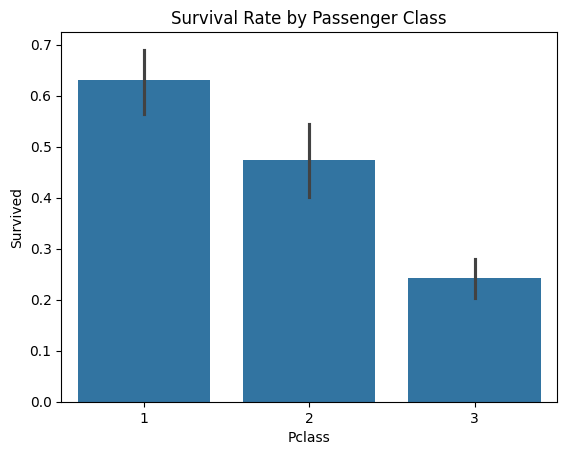

In [19]:
# Survival rate for each passenger class
sns.barplot(x="Pclass", y="Survived", data=df)
plt.title("Survival Rate by Passenger Class")
plt.show()

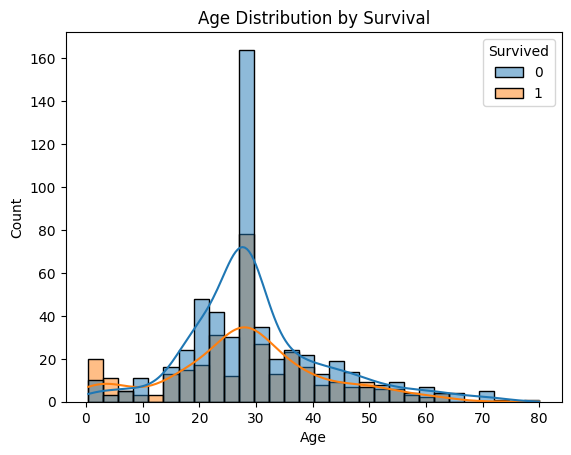

In [20]:
# Age distribution of survivors vs non-survivors
sns.histplot(data=df, x="Age", hue="Survived", bins=30, kde=True)
plt.title("Age Distribution by Survival")
plt.show()

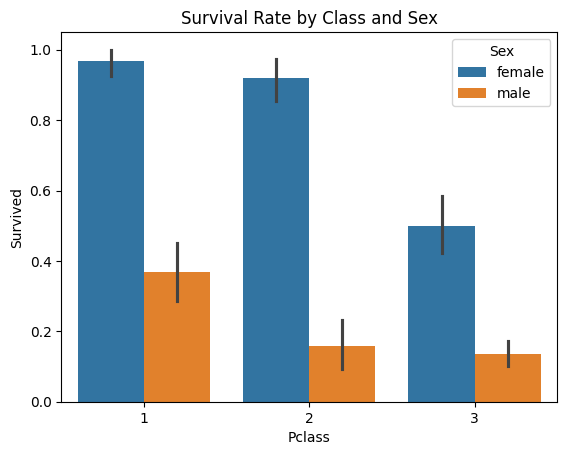

In [21]:
# Survival rate by class, split by sex
sns.barplot(x="Pclass", y="Survived", hue="Sex", data=df)
plt.title("Survival Rate by Class and Sex")
plt.show()

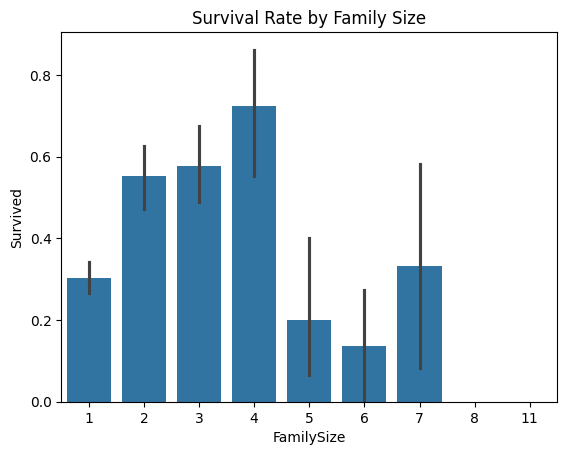

In [22]:
# Create a new feature: total family members on board
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

# Survival rate by family size
sns.barplot(x="FamilySize", y="Survived", data=df)
plt.title("Survival Rate by Family Size")
plt.show()

In [23]:
# Survival rate in percentage for sex and class
print(df.groupby("Sex")["Survived"].mean() * 100)
print(df.groupby("Pclass")["Survived"].mean() * 100)

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64
Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


## Conclusion
- About 38% of passengers survived.
- Women survived far more often (74%) than men (19%).
- Higher class meant better chances: 63% in 1st class vs 24% in 3rd class.
- Young children had better survival chances.
- Small families (2 to 4 people) survived more than people travelling alone or in large families.
- Sex and class together were the strongest factors.

In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Columns the model will learn from
features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]

# Convert text columns into numbers
X = pd.get_dummies(df[features])
y = df["Survived"]

# 80% data for learning, 20% data for testing
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Check how accurate the model is
predictions = model.predict(X_val)
print("Accuracy:", accuracy_score(y_val, predictions))

Accuracy: 0.8044692737430168


In [25]:
# Load the new passengers (test data)
test = pd.read_csv("/kaggle/input/competitions/titanic/test.csv")
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [26]:
# Fill missing Age and Fare in test data using values from the training data
test["Age"] = test["Age"].fillna(df["Age"].median())
test["Fare"] = test["Fare"].fillna(df["Fare"].median())

# Check that the columns we need have no missing values
test[["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]].isnull().sum()

Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [27]:
# Prepare test data the same way as training data
X_test = pd.get_dummies(test[features])
X_test = X_test.reindex(columns=X.columns, fill_value=0)

# Train the final model on ALL 891 passengers
final_model = RandomForestClassifier(n_estimators=100, random_state=42)
final_model.fit(X, y)

# Predict survival for the 418 test passengers
test_predictions = final_model.predict(X_test)

# Create the submission file
submission = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Survived": test_predictions
})
submission.to_csv("submission.csv", index=False)
submission.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,1
4,896,0


In [29]:
# Extract title (Mr, Mrs, Miss...) from the Name column
for data in [df, test]:
    data["Title"] = data["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)
    data["Title"] = data["Title"].replace(
        ["Lady", "Countess", "Capt", "Col", "Don", "Dr", "Major",
         "Rev", "Sir", "Jonkheer", "Dona"], "Rare")
    data["Title"] = data["Title"].replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})
    data["FamilySize"] = data["SibSp"] + data["Parch"] + 1

# New list of columns for the model
features2 = ["Pclass", "Sex", "Age", "Fare", "Embarked", "Title", "FamilySize"]

# Prepare data and test the new model
X2 = pd.get_dummies(df[features2])
X2_train, X2_val, y2_train, y2_val = train_test_split(X2, y, test_size=0.2, random_state=42)

model2 = RandomForestClassifier(n_estimators=100, random_state=42)
model2.fit(X2_train, y2_train)
print("New Accuracy:", accuracy_score(y2_val, model2.predict(X2_val)))

New Accuracy: 0.8156424581005587


In [30]:
# Prepare training and test data with the new features
X2_all = pd.get_dummies(df[features2])
X2_test = pd.get_dummies(test[features2])
X2_test = X2_test.reindex(columns=X2_all.columns, fill_value=0)

# Train the new model on ALL 891 passengers
final_model2 = RandomForestClassifier(n_estimators=100, random_state=42)
final_model2.fit(X2_all, y)

# Predict survival for the 418 test passengers
test_predictions2 = final_model2.predict(X2_test)

# Create the new submission file
submission2 = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Survived": test_predictions2
})
submission2.to_csv("submission.csv", index=False)
submission2.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,1
4,896,1


In [31]:
from sklearn.model_selection import cross_val_score

# Compare both models using 5-fold cross-validation
scores1 = cross_val_score(RandomForestClassifier(n_estimators=100, random_state=42), X, y, cv=5)
scores2 = cross_val_score(RandomForestClassifier(n_estimators=100, random_state=42), X2, y, cv=5)

print("Model 1 average accuracy:", scores1.mean())
print("Model 2 average accuracy:", scores2.mean())

Model 1 average accuracy: 0.8103571652752495
Model 2 average accuracy: 0.8047078023978408


In [32]:
# Try different tree depths and compare using 5-fold cross-validation
for depth in [3, 4, 5, 6, 8, None]:
    model = RandomForestClassifier(n_estimators=100, max_depth=depth, min_samples_leaf=2, random_state=42)
    score1 = cross_val_score(model, X, y, cv=5).mean()
    score2 = cross_val_score(model, X2, y, cv=5).mean()
    print("max_depth =", depth, "| Model 1:", round(score1, 4), "| Model 2:", round(score2, 4))

max_depth = 3 | Model 1: 0.8058 | Model 2: 0.8182
max_depth = 4 | Model 1: 0.8148 | Model 2: 0.8294
max_depth = 5 | Model 1: 0.8249 | Model 2: 0.8294
max_depth = 6 | Model 1: 0.8227 | Model 2: 0.8272
max_depth = 8 | Model 1: 0.8317 | Model 2: 0.8317
max_depth = None | Model 1: 0.8305 | Model 2: 0.8305


In [33]:
# Final model: new features (Title, FamilySize) with shallow trees
final_model3 = RandomForestClassifier(n_estimators=100, max_depth=5, min_samples_leaf=2, random_state=42)
final_model3.fit(X2_all, y)

# Predict survival for the 418 test passengers
test_predictions3 = final_model3.predict(X2_test)

# Create the new submission file
submission3 = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Survived": test_predictions3
})
submission3.to_csv("submission.csv", index=False)
submission3.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


## Model Results
- Baseline Random Forest: 0.76555 on the leaderboard.
- Adding Title and FamilySize alone did not help (0.75119).
- Limiting tree depth (max_depth=5) reduced overfitting and gave the best score: 0.77990.
- Lesson: compare models with cross-validation, not a single train/validation split.